## EDA — DataTour Mobile Money Fraud Detection

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

### Configuration

In [3]:
DATA_DIR = Path('dataset')
OUT_DIR = Path('eda_plots')
OUT_DIR.mkdir(exist_ok=True)
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4d",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#2d3142",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "DejaVu Sans",
})

FRAUD_COLOR = "#f85149"
LEGIT_COLOR = "#3fb950"
ACCENT_COLOR = "#58a6ff"

print("Chargement des donnée...")
train = pd.read_csv(DATA_DIR/"train.csv")
test = pd.read_csv(DATA_DIR/"test.csv")
print(f"  train : {train.shape} | test : {test.shape}")

Chargement des donnée...
  train : (1290081, 11) | test : (430100, 10)


### Apperçu des données des datasets

In [4]:
print("Data set d'entrainement\n")
print(train.head(2))

Data set d'entrainement

                     id  period operation  amount          origin_account  \
0  dtf_0000001_ffa5beb5       0     op_05  636.75  acc_o_307358626ad66fed   
1  dtf_0000002_61992e82       0     op_05  636.12  acc_o_aeb690c57bf5d1de   

   origin_balance_before  origin_balance_after     destination_account  \
0                  87.00               -549.75  acc_d_7fac3b16af7d127b   
1                  76.93                 76.93  acc_d_1d6120e8b117aa14   

   destination_balance_before  destination_balance_after  fraud_flag  
0                      630.88                    1267.62           0  
1                      731.70                     731.70           0  


In [5]:
print("Data set de test\n")
print(test.head(2))

Data set de test

                     id  period operation    amount          origin_account  \
0  dtf_0000001_08a8a524     106     op_05    655.40  acc_o_401632acdfdd0cf6   
1  dtf_0000002_ae0d3769     106     op_03  19981.95  acc_o_c37d560fee7f4b9c   

   origin_balance_before  origin_balance_after     destination_account  \
0             1125122.27            1124466.87  acc_d_35693a9b1dddbf63   
1             2929676.45            2909694.52  acc_d_701f0b161689ca25   

   destination_balance_before  destination_balance_after  
0                   197596.66                  198252.07  
1                        0.00                   19981.95  


### Feature dérivées des données

In [6]:
train['orig_chg'] = train['origin_balance_after'] - train['origin_balance_before']
train['dest_chg'] = train['destination_balance_after'] - train['destination_balance_before']
train['amount_log'] = np.log1p(train['amount'])
train['orig_no_move'] = ((train['orig_chg'].abs() < 0.01) & (train['amount'] > 0)).astype(int)
train['dest_no_move'] = ((train['dest_chg'].abs() < 0.01) & (train['amount'] > 0)).astype(int)

fraud = train[train['fraud_flag'] == 1]
legit = train[train['fraud_flag'] == 0]

### FIGURE 1 - Vue d'ensemble

Figure 1 — Vue d'ensemble...


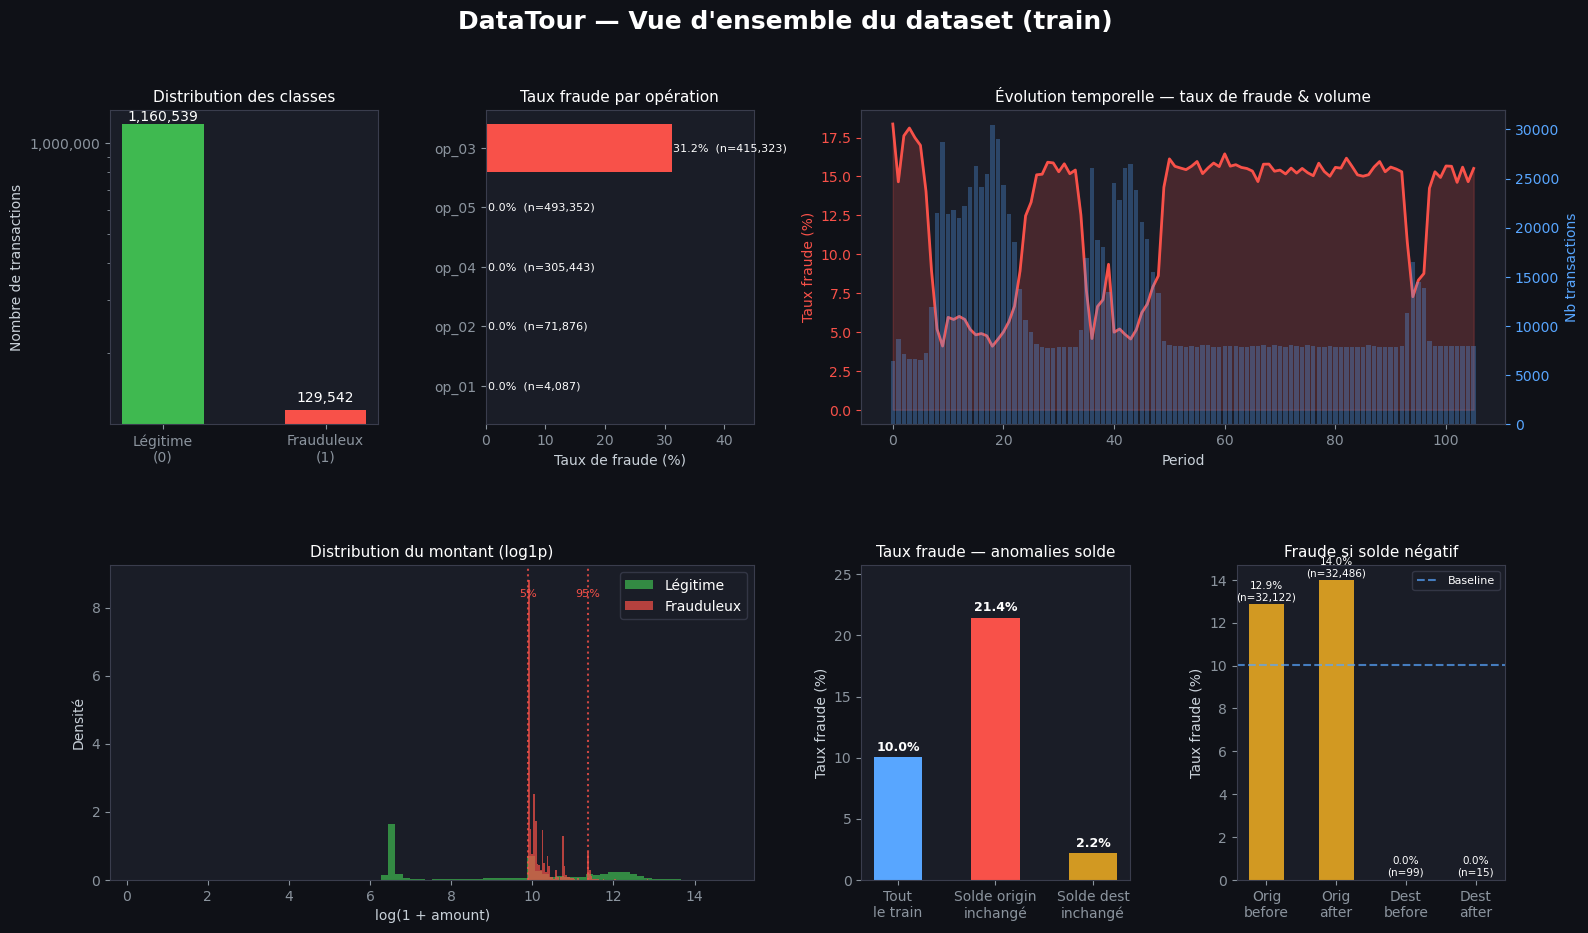

   01_vue_ensemble.png


In [7]:
print("Figure 1 — Vue d'ensemble...")
fig = plt.figure(figsize=(18, 10), facecolor="#0f1117")
fig.suptitle("DataTour — Vue d'ensemble du dataset (train)", fontsize=18,
             color="white", fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

# 1a — Distribution fraude/légit
ax = fig.add_subplot(gs[0, 0])
counts = train["fraud_flag"].value_counts()
bars = ax.bar(["Légitime\n(0)", "Frauduleux\n(1)"],
              counts.values,
              color=[LEGIT_COLOR, FRAUD_COLOR], width=0.5, edgecolor="none")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5000,
            f"{b.get_height():,}", ha="center", va="bottom", fontsize=10, color="white")
ax.set_title("Distribution des classes", color="white", fontsize=11)
ax.set_ylabel("Nombre de transactions")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# 1b — Taux fraude par opération
ax = fig.add_subplot(gs[0, 1])
op_stats = train.groupby("operation")["fraud_flag"].agg(["mean", "count"]).reset_index()
op_stats = op_stats.sort_values("mean", ascending=True)
colors = [FRAUD_COLOR if m > 0 else "#3a3d4d" for m in op_stats["mean"]]
ax.barh(op_stats["operation"], op_stats["mean"] * 100, color=colors, edgecolor="none")
for i, (_, row) in enumerate(op_stats.iterrows()):
    ax.text(row["mean"] * 100 + 0.3, i, f'{row["mean"]:.1%}  (n={row["count"]:,})',
            va="center", fontsize=8, color="white")
ax.set_title("Taux fraude par opération", color="white", fontsize=11)
ax.set_xlabel("Taux de fraude (%)")
ax.set_xlim(0, 45)

# 1c — Fraude par period (évolution temporelle)
ax = fig.add_subplot(gs[0, 2:])
period_stats = train.groupby("period")["fraud_flag"].agg(["mean", "count"]).reset_index()
ax2 = ax.twinx()
ax.plot(period_stats["period"], period_stats["mean"] * 100,
        color=FRAUD_COLOR, linewidth=2, label="Taux fraude (%)")
ax.fill_between(period_stats["period"], period_stats["mean"] * 100,
                alpha=0.2, color=FRAUD_COLOR)
ax2.bar(period_stats["period"], period_stats["count"],
        color=ACCENT_COLOR, alpha=0.3, label="Nb transactions")
ax.set_title("Évolution temporelle — taux de fraude & volume", color="white", fontsize=11)
ax.set_xlabel("Period")
ax.set_ylabel("Taux fraude (%)", color=FRAUD_COLOR)
ax2.set_ylabel("Nb transactions", color=ACCENT_COLOR)
ax.tick_params(axis="y", colors=FRAUD_COLOR)
ax2.tick_params(axis="y", colors=ACCENT_COLOR)

# 1d — Distribution des montants (log)
ax = fig.add_subplot(gs[1, :2])
ax.hist(np.log1p(legit["amount"]),  bins=80, color=LEGIT_COLOR,  alpha=0.7, label="Légitime",    density=True)
ax.hist(np.log1p(fraud["amount"]),  bins=80, color=FRAUD_COLOR,  alpha=0.7, label="Frauduleux",  density=True)
ax.set_title("Distribution du montant (log1p)", color="white", fontsize=11)
ax.set_xlabel("log(1 + amount)")
ax.set_ylabel("Densité")
ax.legend(facecolor="#1a1d27", edgecolor="#3a3d4d", labelcolor="white")
# Annotations quantiles fraude
q5, q95 = np.log1p(fraud["amount"].quantile([0.05, 0.95]))
ax.axvline(q5,  color=FRAUD_COLOR, linestyle=":", alpha=0.8)
ax.axvline(q95, color=FRAUD_COLOR, linestyle=":", alpha=0.8)
ax.text(q5,  ax.get_ylim()[1]*0.9, "5%",  color=FRAUD_COLOR, fontsize=8, ha="center")
ax.text(q95, ax.get_ylim()[1]*0.9, "95%", color=FRAUD_COLOR, fontsize=8, ha="center")

# 1e — Anomalies de solde
ax = fig.add_subplot(gs[1, 2])
groups = ["Tout\nle train", "Solde origin\ninchangé", "Solde dest\ninchangé"]
rates = [
    train["fraud_flag"].mean() * 100,
    train.loc[train["orig_no_move"] == 1, "fraud_flag"].mean() * 100,
    train.loc[train["dest_no_move"] == 1,  "fraud_flag"].mean() * 100,
]
bar_colors = [ACCENT_COLOR, FRAUD_COLOR, "#d29922"]
bars = ax.bar(groups, rates, color=bar_colors, width=0.5, edgecolor="none")
for b, r in zip(bars, rates):
    ax.text(b.get_x() + b.get_width()/2, r + 0.3, f"{r:.1f}%",
            ha="center", va="bottom", fontsize=9, color="white", fontweight="bold")
ax.set_title("Taux fraude — anomalies solde", color="white", fontsize=11)
ax.set_ylabel("Taux fraude (%)")
ax.set_ylim(0, max(rates) * 1.2)

# 1f — Soldes négatifs
ax = fig.add_subplot(gs[1, 3])
neg_cols = ["origin_balance_before", "origin_balance_after",
            "destination_balance_before", "destination_balance_after"]
neg_labels = ["Orig\nbefore", "Orig\nafter", "Dest\nbefore", "Dest\nafter"]
neg_rates = [train.loc[train[c] < 0, "fraud_flag"].mean() * 100 for c in neg_cols]
neg_counts = [(train[c] < 0).sum() for c in neg_cols]
bars = ax.bar(neg_labels, neg_rates, color="#d29922", width=0.5, edgecolor="none")
for b, r, n in zip(bars, neg_rates, neg_counts):
    ax.text(b.get_x() + b.get_width()/2, r + 0.1, f"{r:.1f}%\n(n={n:,})",
            ha="center", va="bottom", fontsize=7.5, color="white")
ax.set_title("Fraude si solde négatif", color="white", fontsize=11)
ax.set_ylabel("Taux fraude (%)")
ax.axhline(train["fraud_flag"].mean() * 100, color=ACCENT_COLOR,
           linestyle="--", alpha=0.7, label="Baseline")
ax.legend(facecolor="#1a1d27", edgecolor="#3a3d4d", labelcolor="white", fontsize=8)
plt.show()
plt.savefig(OUT_DIR / "01_vue_ensemble.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.close()
print("   01_vue_ensemble.png")


### FIGURE 2 — Analyse des montants & soldes

Figure 2 — Analyse montants & soldes...


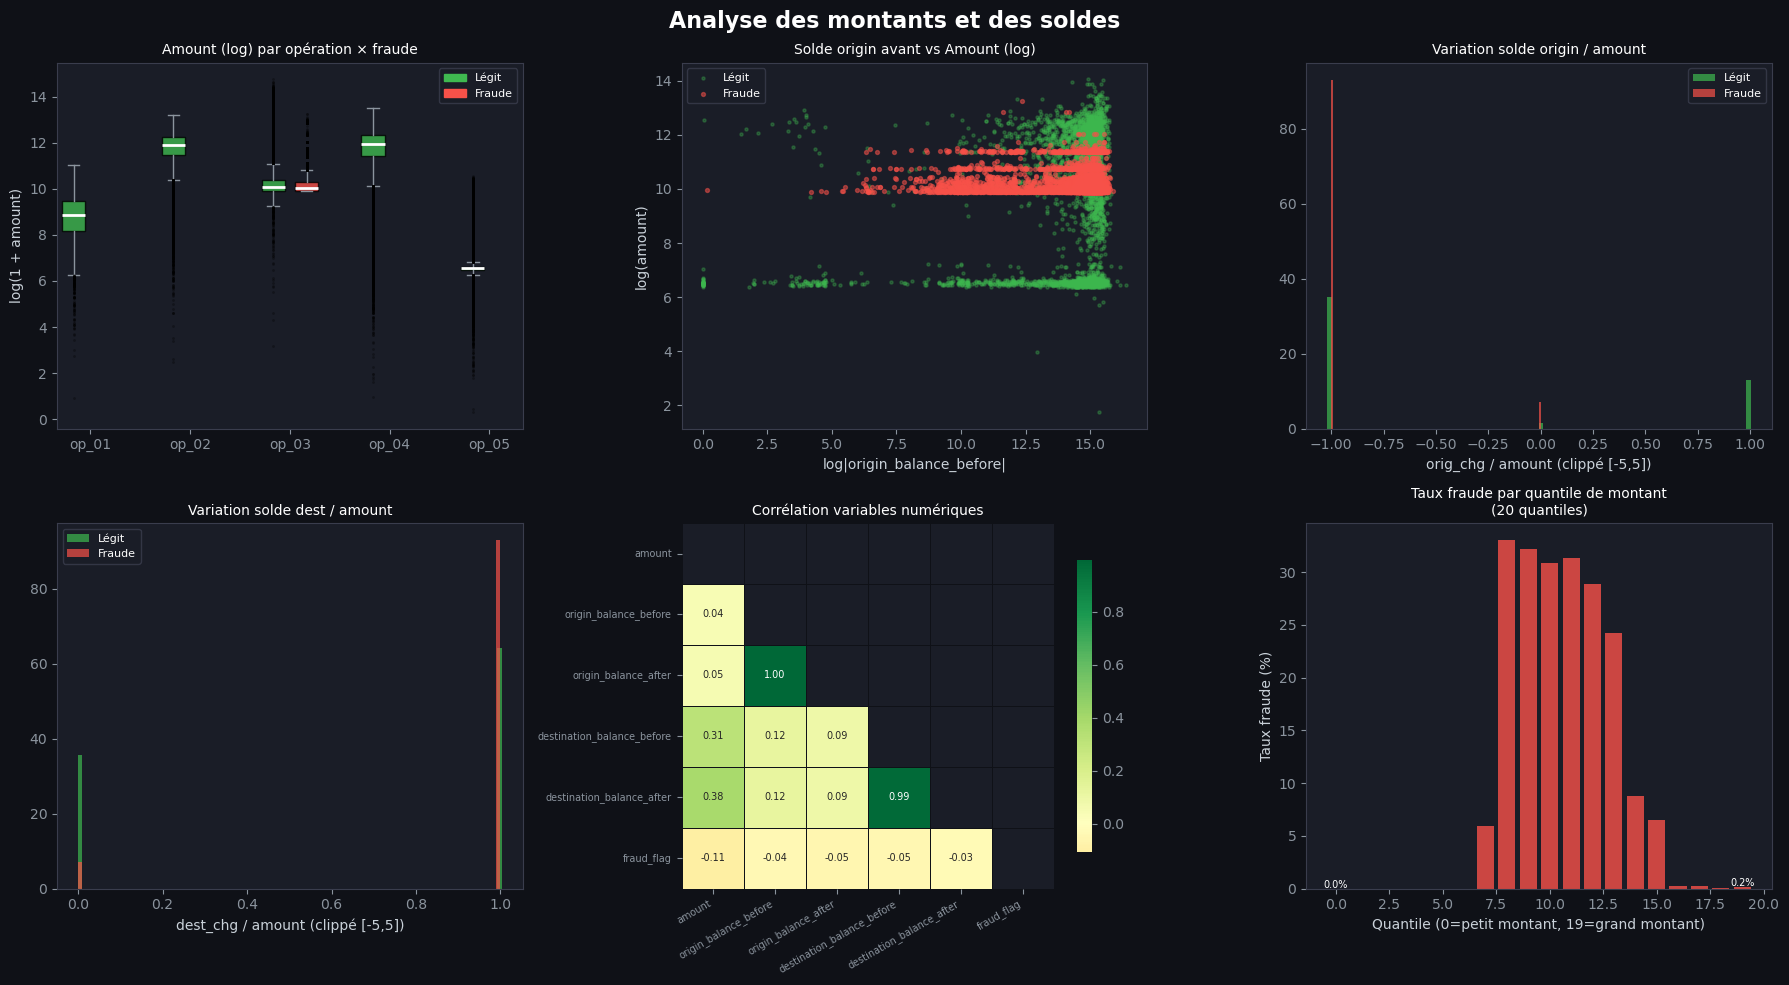

   02_montants_soldes.png


In [8]:
print("Figure 2 — Analyse montants & soldes...")
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor="#0f1117")
fig.suptitle("Analyse des montants et des soldes", fontsize=16,
             color="white", fontweight="bold", y=0.98)

# Boxplot amount par opération et fraude
ax = axes[0, 0]
op_order = ["op_01", "op_02", "op_03", "op_04", "op_05"]
data_box = [train.loc[(train["operation"] == op) & (train["fraud_flag"] == f), "amount_log"].values
            for op in op_order for f in [0, 1]]
positions = []
colors_box = []
for i, op in enumerate(op_order):
    positions += [i*3, i*3+1]
    colors_box += [LEGIT_COLOR, FRAUD_COLOR]
bp = ax.boxplot(data_box, positions=positions, widths=0.7, patch_artist=True,
                medianprops=dict(color="white", linewidth=2),
                whiskerprops=dict(color="#8b949e"),
                capprops=dict(color="#8b949e"),
                flierprops=dict(marker=".", color="#8b949e", alpha=0.3, markersize=2))
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticks([i*3+0.5 for i in range(len(op_order))])
ax.set_xticklabels(op_order)
ax.set_title("Amount (log) par opération × fraude", color="white", fontsize=10)
ax.set_ylabel("log(1 + amount)")
from matplotlib.patches import Patch
ax.legend([Patch(color=LEGIT_COLOR), Patch(color=FRAUD_COLOR)],
          ["Légit", "Fraude"], facecolor="#1a1d27", edgecolor="#3a3d4d",
          labelcolor="white", fontsize=8)

# Scatter origin_before vs amount (fraude vs légit)
ax = axes[0, 1]
sample_l = legit.sample(min(5000, len(legit)), random_state=42)
sample_f = fraud.sample(min(5000, len(fraud)), random_state=42)
ax.scatter(np.log1p(np.abs(sample_l["origin_balance_before"])),
           sample_l["amount_log"], color=LEGIT_COLOR, alpha=0.3, s=5, label="Légit")
ax.scatter(np.log1p(np.abs(sample_f["origin_balance_before"])),
           sample_f["amount_log"], color=FRAUD_COLOR, alpha=0.5, s=8, label="Fraude")
ax.set_title("Solde origin avant vs Amount (log)", color="white", fontsize=10)
ax.set_xlabel("log|origin_balance_before|")
ax.set_ylabel("log(amount)")
ax.legend(facecolor="#1a1d27", edgecolor="#3a3d4d", labelcolor="white", fontsize=8)

# Distribution orig_chg
ax = axes[0, 2]
clip = 5
ax.hist(np.clip(legit["orig_chg"] / (legit["amount"] + 1e-6), -clip, clip),
        bins=100, color=LEGIT_COLOR, alpha=0.7, density=True, label="Légit")
ax.hist(np.clip(fraud["orig_chg"] / (fraud["amount"] + 1e-6), -clip, clip),
        bins=100, color=FRAUD_COLOR, alpha=0.7, density=True, label="Fraude")
ax.set_title("Variation solde origin / amount", color="white", fontsize=10)
ax.set_xlabel("orig_chg / amount (clippé [-5,5])")
ax.legend(facecolor="#1a1d27", edgecolor="#3a3d4d", labelcolor="white", fontsize=8)

# Distribution dest_chg / amount
ax = axes[1, 0]
ax.hist(np.clip(legit["dest_chg"] / (legit["amount"] + 1e-6), -clip, clip),
        bins=100, color=LEGIT_COLOR, alpha=0.7, density=True, label="Légit")
ax.hist(np.clip(fraud["dest_chg"] / (fraud["amount"] + 1e-6), -clip, clip),
        bins=100, color=FRAUD_COLOR, alpha=0.7, density=True, label="Fraude")
ax.set_title("Variation solde dest / amount", color="white", fontsize=10)
ax.set_xlabel("dest_chg / amount (clippé [-5,5])")
ax.legend(facecolor="#1a1d27", edgecolor="#3a3d4d", labelcolor="white", fontsize=8)

# Heatmap corrélation
ax = axes[1, 1]
num_cols = ["amount", "origin_balance_before", "origin_balance_after",
            "destination_balance_before", "destination_balance_after", "fraud_flag"]
corr = train[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, linecolor="#0f1117",
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
ax.set_title("Corrélation variables numériques", color="white", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)

# Fraude par quantile de montant
ax = axes[1, 2]
train["amount_q"] = pd.qcut(train["amount"], q=20, labels=False)
q_stats = train.groupby("amount_q")["fraud_flag"].mean()
q_midpoints = train.groupby("amount_q")["amount"].median()
ax.bar(range(len(q_stats)), q_stats.values * 100, color=FRAUD_COLOR, edgecolor="none", alpha=0.8)
ax.set_title("Taux fraude par quantile de montant\n(20 quantiles)", color="white", fontsize=10)
ax.set_xlabel("Quantile (0=petit montant, 19=grand montant)")
ax.set_ylabel("Taux fraude (%)")
# Annoter les quantiles extrêmes
for i, v in enumerate(q_stats.values * 100):
    if i in [0, 19]:
        ax.text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=7, color="white")

plt.tight_layout()
plt.show()
plt.savefig(OUT_DIR / "02_montants_soldes.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.close()
print("   02_montants_soldes.png")


### FIGURE 3 — Analyse des comptes (comportementale)

Figure 3 — Analyse comportementale des comptes...


/tmp/ipykernel_495604/2852866335.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate_by_freq = orig_stats.groupby(bins)["fraud_rate"].mean() * 100


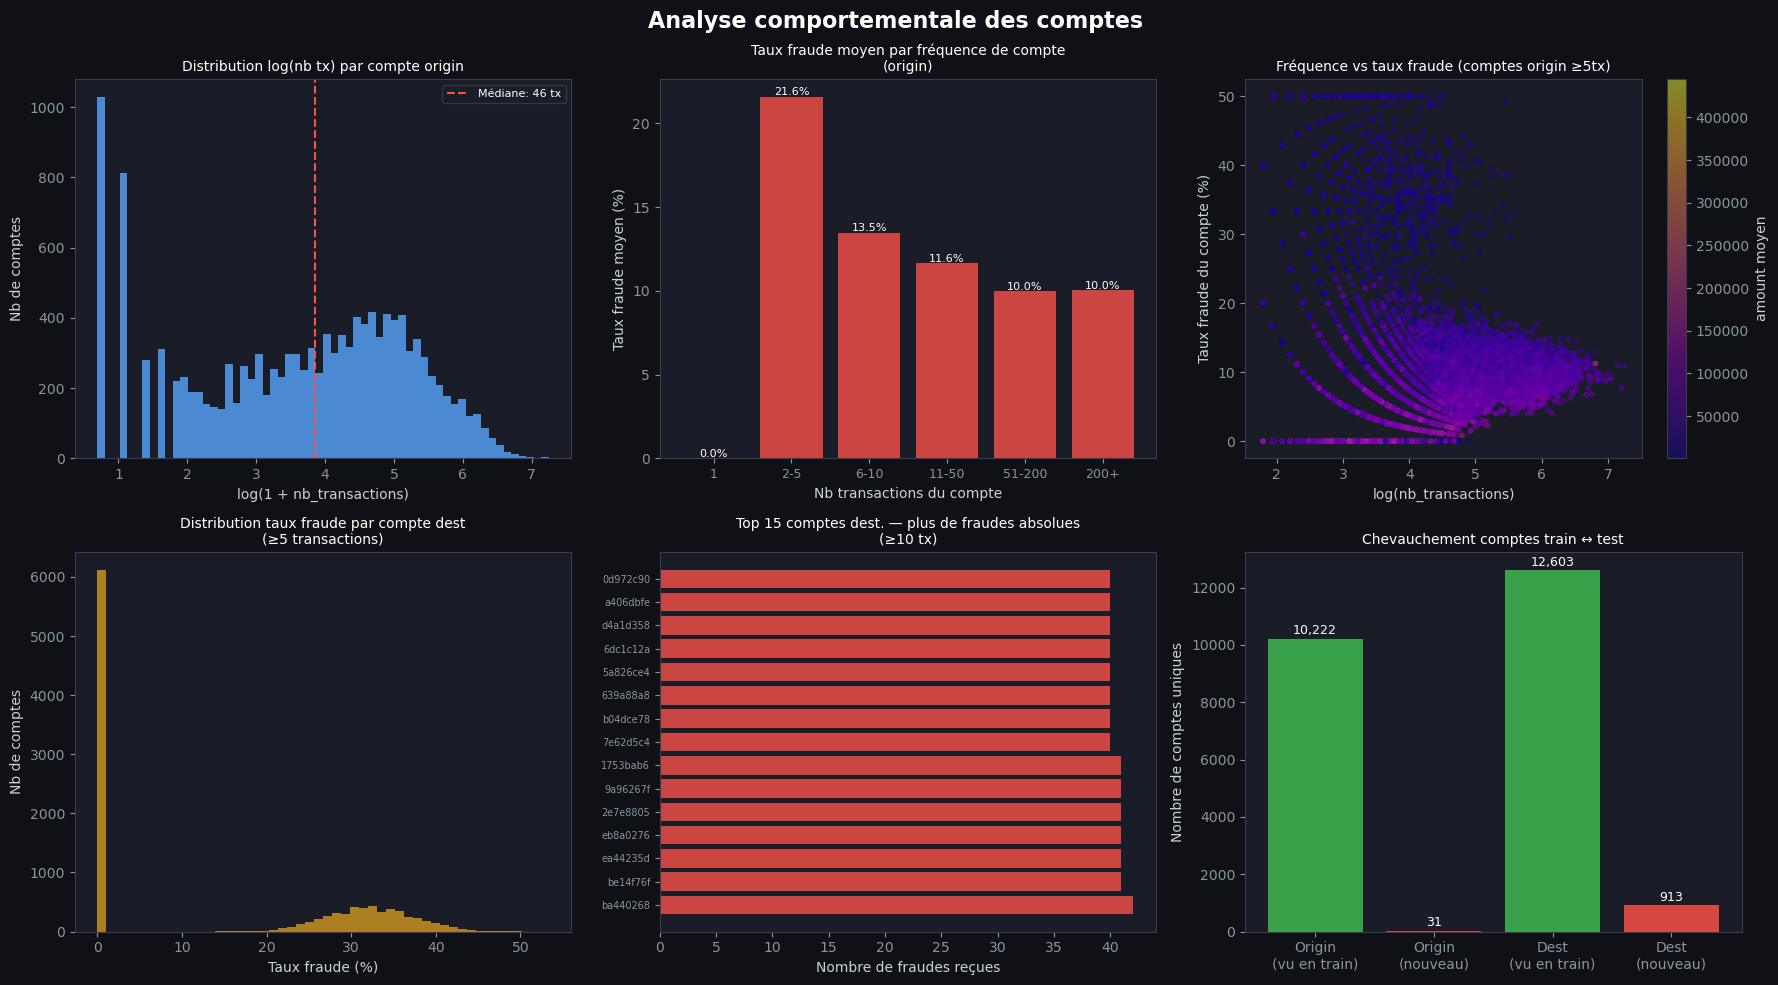

   03_comptes_comportement.png


In [9]:
print("Figure 3 — Analyse comportementale des comptes...")

# Stats par compte émetteur
orig_stats = train.groupby("origin_account").agg(
    n_tx=("fraud_flag", "count"),
    fraud_rate=("fraud_flag", "mean"),
    total_fraud=("fraud_flag", "sum"),
    amount_mean=("amount", "mean"),
    amount_std=("amount", "std"),
).fillna(0)

dest_stats = train.groupby("destination_account").agg(
    n_tx=("fraud_flag", "count"),
    fraud_rate=("fraud_flag", "mean"),
    total_fraud=("fraud_flag", "sum"),
    amount_mean=("amount", "mean"),
).fillna(0)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor="#0f1117")
fig.suptitle("Analyse comportementale des comptes", fontsize=16,
             color="white", fontweight="bold", y=0.98)

# Distribution du nombre de tx par compte origin
ax = axes[0, 0]
ax.hist(np.log1p(orig_stats["n_tx"]), bins=60, color=ACCENT_COLOR, alpha=0.8, edgecolor="none")
ax.set_title("Distribution log(nb tx) par compte origin", color="white", fontsize=10)
ax.set_xlabel("log(1 + nb_transactions)")
ax.set_ylabel("Nb de comptes")
ax.axvline(np.log1p(orig_stats["n_tx"].median()), color=FRAUD_COLOR,
           linestyle="--", label=f"Médiane: {orig_stats['n_tx'].median():.0f} tx")
ax.legend(facecolor="#1a1d27", edgecolor="#3a3d4d", labelcolor="white", fontsize=8)

# Taux fraude vs nb transactions (compte origin)
ax = axes[0, 1]
bins = pd.cut(orig_stats["n_tx"], bins=[0,1,5,10,50,200,np.inf],
              labels=["1","2-5","6-10","11-50","51-200","200+"])
rate_by_freq = orig_stats.groupby(bins)["fraud_rate"].mean() * 100
ax.bar(range(len(rate_by_freq)), rate_by_freq.values, color=FRAUD_COLOR,
       edgecolor="none", alpha=0.8)
ax.set_xticks(range(len(rate_by_freq)))
ax.set_xticklabels(rate_by_freq.index, fontsize=9)
ax.set_title("Taux fraude moyen par fréquence de compte\n(origin)", color="white", fontsize=10)
ax.set_xlabel("Nb transactions du compte")
ax.set_ylabel("Taux fraude moyen (%)")
for i, v in enumerate(rate_by_freq.values):
    ax.text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=8, color="white")

# Scatter n_tx vs fraud_rate (origin, comptes avec ≥5 tx)
ax = axes[0, 2]
sub = orig_stats[orig_stats["n_tx"] >= 5]
sc = ax.scatter(np.log1p(sub["n_tx"]), sub["fraud_rate"] * 100,
                c=sub["amount_mean"], cmap="plasma", alpha=0.5, s=10)
plt.colorbar(sc, ax=ax, label="amount moyen")
ax.set_title("Fréquence vs taux fraude (comptes origin ≥5tx)", color="white", fontsize=10)
ax.set_xlabel("log(nb_transactions)")
ax.set_ylabel("Taux fraude du compte (%)")

# Distribution taux fraude par compte dest
ax = axes[1, 0]
dest_sub = dest_stats[dest_stats["n_tx"] >= 5]
ax.hist(dest_sub["fraud_rate"] * 100, bins=50, color="#d29922", alpha=0.8, edgecolor="none")
ax.set_title("Distribution taux fraude par compte dest\n(≥5 transactions)", color="white", fontsize=10)
ax.set_xlabel("Taux fraude (%)")
ax.set_ylabel("Nb de comptes")

# Top comptes destinataires les plus frauduleux
ax = axes[1, 1]
top_dest = dest_stats[dest_stats["n_tx"] >= 10].nlargest(15, "total_fraud")
ax.barh(range(len(top_dest)), top_dest["total_fraud"].values, color=FRAUD_COLOR,
        edgecolor="none", alpha=0.8)
ax.set_yticks(range(len(top_dest)))
ax.set_yticklabels([acc[-8:] for acc in top_dest.index], fontsize=7)
ax.set_title("Top 15 comptes dest. — plus de fraudes absolues\n(≥10 tx)", color="white", fontsize=10)
ax.set_xlabel("Nombre de fraudes reçues")

# Comptes partagés train/test
ax = axes[1, 2]
orig_in_test  = set(test["origin_account"]) & set(train["origin_account"])
orig_only_test= set(test["origin_account"]) - set(train["origin_account"])
dest_in_test  = set(test["destination_account"]) & set(train["destination_account"])
dest_only_test= set(test["destination_account"]) - set(train["destination_account"])
categories = ["Origin\n(vu en train)", "Origin\n(nouveau)", "Dest\n(vu en train)", "Dest\n(nouveau)"]
values = [len(orig_in_test), len(orig_only_test), len(dest_in_test), len(dest_only_test)]
colors_v = [LEGIT_COLOR, FRAUD_COLOR, LEGIT_COLOR, FRAUD_COLOR]
bars = ax.bar(categories, values, color=colors_v, edgecolor="none", alpha=0.85)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 50, f"{v:,}",
            ha="center", va="bottom", fontsize=9, color="white")
ax.set_title("Chevauchement comptes train ↔ test", color="white", fontsize=10)
ax.set_ylabel("Nombre de comptes uniques")

plt.tight_layout()
plt.show()
plt.savefig(OUT_DIR / "03_comptes_comportement.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.close()
print("   03_comptes_comportement.png")

### RÉSUMÉ STATISTIQUE

In [10]:
print("\n" + "="*60)
print("RÉSUMÉ EDA — INSIGHTS CLÉS")
print("="*60)

print(f"\n  Dataset: train={train.shape}, test={test.shape}")
print(f"Taux de fraude: {train['fraud_flag'].mean():.4%}")
print(f"\nOpérations:")
for op, row in train.groupby("operation")["fraud_flag"].agg(["mean","count"]).iterrows():
    flag = "FRAUDE" if row["mean"] > 0 else "LÉGIT"
    print(f"   {op}: {row['mean']:.2%} fraude ({row['count']:,} tx) — {flag}")

print(f"\nAnomalies de solde:")
print(f"   Solde origin inchangé malgré amount>0: {train['orig_no_move'].sum():,} ({train['orig_no_move'].mean():.2%})")
print(f"   → Taux fraude dans ce cas: {train.loc[train['orig_no_move']==1,'fraud_flag'].mean():.2%}")
print(f"   Solde dest inchangé malgré amount>0: {train['dest_no_move'].sum():,} ({train['dest_no_move'].mean():.2%})")

print(f"\nMontants:")
print(f"   Médiane légit:   {legit['amount'].median():>12,.2f}")
print(f"   Médiane fraude:  {fraud['amount'].median():>12,.2f}")
print(f"   → La fraude se concentre sur des montants PLUS PETITS et dans une PLAGE ÉTROITE")

print(f"\nComptes:")
print(f"   origin: {train['origin_account'].nunique():,} uniques (chevauchement test: {len(orig_in_test):,})")
print(f"   dest:   {train['destination_account'].nunique():,} uniques (chevauchement test: {len(dest_in_test):,})")

print(f"\nGraphiques sauvegardés dans: {OUT_DIR.resolve()}/")
print("   01_vue_ensemble.png")
print("   02_montants_soldes.png")
print("   03_comptes_comportement.png")



RÉSUMÉ EDA — INSIGHTS CLÉS

  Dataset: train=(1290081, 17), test=(430100, 10)
Taux de fraude: 10.0414%

Opérations:
   op_01: 0.00% fraude (4,087.0 tx) — LÉGIT
   op_02: 0.00% fraude (71,876.0 tx) — LÉGIT
   op_03: 31.19% fraude (415,323.0 tx) — FRAUDE
   op_04: 0.00% fraude (305,443.0 tx) — LÉGIT
   op_05: 0.00% fraude (493,352.0 tx) — LÉGIT

Anomalies de solde:
   Solde origin inchangé malgré amount>0: 42,821 (3.32%)
   → Taux fraude dans ce cas: 21.44%
   Solde dest inchangé malgré amount>0: 423,821 (32.85%)

Montants:
   Médiane légit:      20,224.37
   Médiane fraude:     23,149.76
   → La fraude se concentre sur des montants PLUS PETITS et dans une PLAGE ÉTROITE

Comptes:
   origin: 13,431 uniques (chevauchement test: 10,222)
   dest:   15,818 uniques (chevauchement test: 12,603)

Graphiques sauvegardés dans: /home/dels/Bureau/DataTour/eda_plots/
   01_vue_ensemble.png
   02_montants_soldes.png
   03_comptes_comportement.png


### Focus : op_03 — la seule opération frauduleuse

Toute la fraude est concentrée dans `op_03`. L'enjeu est donc de **séparer les `op_03` frauduleux des légitimes**.

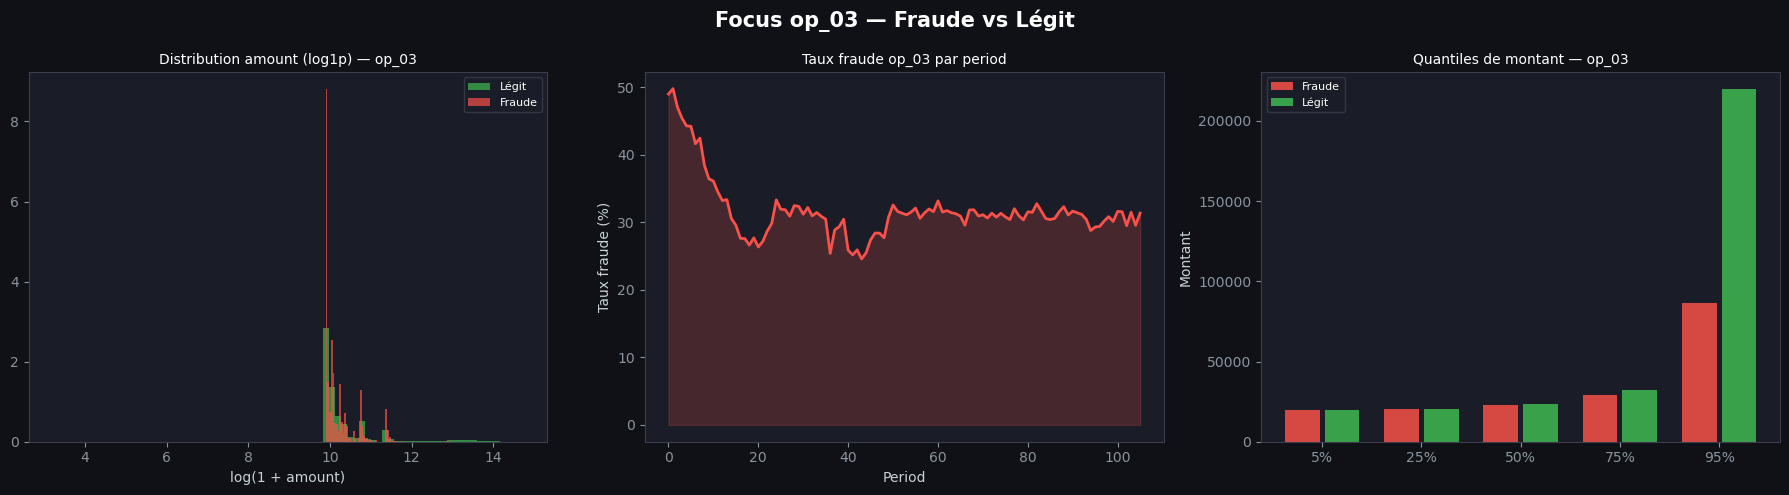

Figure 4 — Focus op_03 générée


In [11]:
op3 = train[train['operation'] == 'op_03'].copy()
op3_fraud = op3[op3['fraud_flag'] == 1]
op3_legit = op3[op3['fraud_flag'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0f1117')
fig.suptitle("Focus op_03 — Fraude vs Légit", fontsize=15, color='white', fontweight='bold')

# 1 — Distribution des montants (log)
ax = axes[0]
ax.hist(np.log1p(op3_legit['amount']), bins=80, color=LEGIT_COLOR, alpha=0.7, density=True, label='Légit')
ax.hist(np.log1p(op3_fraud['amount']), bins=80, color=FRAUD_COLOR, alpha=0.7, density=True, label='Fraude')
ax.set_title('Distribution amount (log1p) — op_03', color='white', fontsize=10)
ax.set_xlabel('log(1 + amount)')
ax.legend(facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='white', fontsize=8)

# 2 — Taux fraude par period dans op_03
ax = axes[1]
op3_period = op3.groupby('period')['fraud_flag'].mean()
ax.plot(op3_period.index, op3_period.values * 100, color=FRAUD_COLOR, linewidth=2)
ax.fill_between(op3_period.index, op3_period.values * 100, alpha=0.2, color=FRAUD_COLOR)
ax.set_title('Taux fraude op_03 par period', color='white', fontsize=10)
ax.set_xlabel('Period')
ax.set_ylabel('Taux fraude (%)')

# 3 — Quantiles de montant: fraude vs legit dans op_03
ax = axes[2]
q_labels = ['5%', '25%', '50%', '75%', '95%']
q_fraud  = [op3_fraud['amount'].quantile(q) for q in [0.05, 0.25, 0.50, 0.75, 0.95]]
q_legit  = [op3_legit['amount'].quantile(q) for q in [0.05, 0.25, 0.50, 0.75, 0.95]]
x = range(len(q_labels))
ax.bar([i - 0.2 for i in x], q_fraud, width=0.35, color=FRAUD_COLOR, label='Fraude', alpha=0.85)
ax.bar([i + 0.2 for i in x], q_legit, width=0.35, color=LEGIT_COLOR, label='Légit', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(q_labels)
ax.set_title('Quantiles de montant — op_03', color='white', fontsize=10)
ax.set_ylabel('Montant')
ax.legend(facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_op03_focus.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Figure 4 — Focus op_03 générée')


### Anomalies comptables — signaux de fraude

Certaines transactions présentent des **incohérences de solde** (solde non débité / non crédité). Ces anomalies sont de bons signaux de fraude.

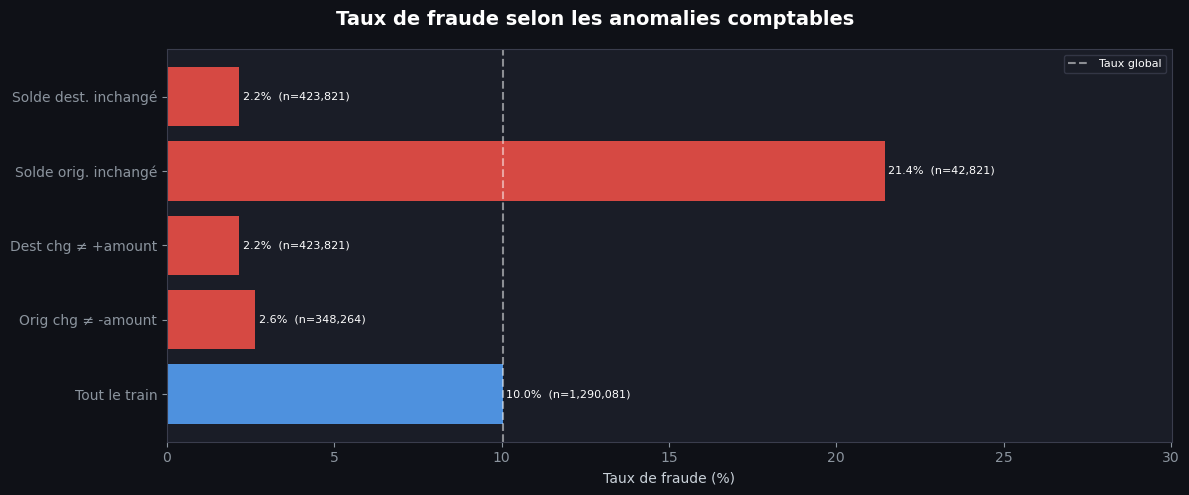

Figure 5 — Anomalies comptables générée


In [12]:
eps = 0.5
train['weird_orig'] = ((train['orig_chg'] + train['amount']).abs() > eps).astype(int)
train['weird_dest'] = ((train['dest_chg'] - train['amount']).abs() > eps).astype(int)

# Taux de fraude par combinaison d'anomalies
groups = [
    ('Tout le train',            train),
    ('Orig chg ≠ -amount',       train[train['weird_orig'] == 1]),
    ('Dest chg ≠ +amount',       train[train['weird_dest'] == 1]),
    ('Solde orig. inchangé',     train[train['orig_no_move'] == 1]),
    ('Solde dest. inchangé',     train[train['dest_no_move'] == 1]),
]

labels = [g[0] for g in groups]
rates  = [g[1]['fraud_flag'].mean() * 100 for g in groups]
counts = [len(g[1]) for g in groups]

fig, ax = plt.subplots(figsize=(12, 5), facecolor='#0f1117')
fig.suptitle('Taux de fraude selon les anomalies comptables', fontsize=14, color='white', fontweight='bold')
bar_colors = [ACCENT_COLOR] + [FRAUD_COLOR] * (len(groups) - 1)
bars = ax.barh(labels, rates, color=bar_colors, edgecolor='none', alpha=0.85)
for b, r, n in zip(bars, rates, counts):
    ax.text(r + 0.1, b.get_y() + b.get_height() / 2,
            f'{r:.1f}%  (n={n:,})', va='center', fontsize=8, color='white')
ax.axvline(train['fraud_flag'].mean() * 100, color='white', linestyle='--', alpha=0.5, label='Taux global')
ax.set_xlabel('Taux de fraude (%)')
ax.set_xlim(0, max(rates) * 1.4)
ax.legend(facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / '05_anomalies_comptables.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Figure 5 — Anomalies comptables générée')


### Dimension temporelle (period)

La variable `period` simule le temps. Le taux de fraude varie fortement selon la période — information utile pour la validation.

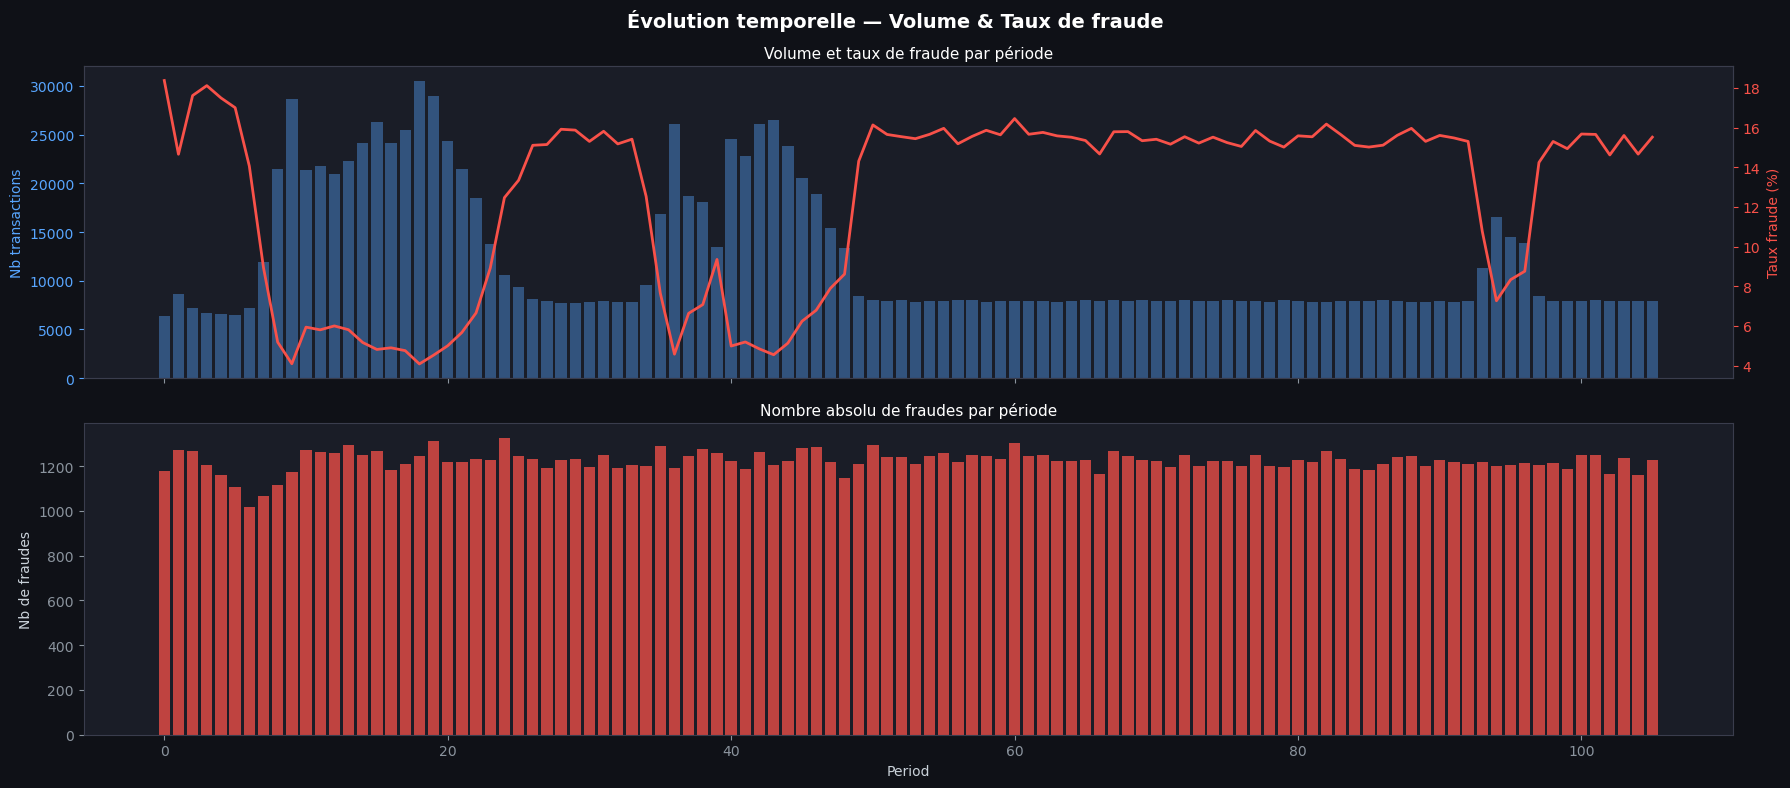

Figure 6 — Dimension temporelle générée


In [13]:
period_stats = train.groupby('period').agg(
    n_tx      = ('fraud_flag', 'count'),
    fraud_rate= ('fraud_flag', 'mean'),
    n_fraud   = ('fraud_flag', 'sum'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(18, 8), facecolor='#0f1117', sharex=True)
fig.suptitle('Évolution temporelle — Volume & Taux de fraude', fontsize=14, color='white', fontweight='bold')

ax = axes[0]
ax2 = ax.twinx()
ax.bar(period_stats['period'], period_stats['n_tx'], color=ACCENT_COLOR, alpha=0.4, label='Nb transactions')
ax2.plot(period_stats['period'], period_stats['fraud_rate'] * 100, color=FRAUD_COLOR, linewidth=2, label='Taux fraude')
ax.set_ylabel('Nb transactions', color=ACCENT_COLOR)
ax2.set_ylabel('Taux fraude (%)', color=FRAUD_COLOR)
ax.tick_params(axis='y', colors=ACCENT_COLOR)
ax2.tick_params(axis='y', colors=FRAUD_COLOR)
ax.set_title('Volume et taux de fraude par période', color='white', fontsize=11)

ax = axes[1]
ax.bar(period_stats['period'], period_stats['n_fraud'], color=FRAUD_COLOR, alpha=0.75, label='Nb fraudes')
ax.set_ylabel('Nb de fraudes')
ax.set_xlabel('Period')
ax.set_title('Nombre absolu de fraudes par période', color='white', fontsize=11)

plt.tight_layout()
plt.savefig(OUT_DIR / '06_period_temporal.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Figure 6 — Dimension temporelle générée')


### Résumé des insights EDA

| # | Insight | Impact modélisation |
|---|---------|---------------------|
| 1 | **100% de la fraude est dans `op_03`** (31.2% de fraude) | `operation` est la feature la plus discriminante — filtrer/encoder |
| 2 | **Plage de montant très étroite pour la fraude** : entre ~19 800 et 560 000 (médiane 23 150) | Feature `amount` + ratios solde |
| 3 | **Solde origin inchangé** → taux fraude 21.4% (vs 10% global) | Flag `orig_no_move` = signal fort |
| 4 | **Variation solde ≠ montant** (weird_orig) → taux fraude 2.6% | Signal faible mais utile |
| 5 | **Taux de fraude varie fortement par period** (4% → 18%) | Valider en 'out-of-time' (split temporel) |
| 6 | **99.7% des comptes origin du test sont connus** en train | Target encoding peu risqué pour ces comptes |
| 7 | **93.2% des comptes dest du test sont connus** en train | Target encoding faisable (attention aux 6.8% nouveaux) |
| 8 | **Aucun compte à 100% frauduleux** (avec ≥5 tx) | Pas de data leakage trivial via les comptes |


In [15]:
print('=== RÉSUMÉ EDA ===')
print(f'Dataset train : {train.shape}  |  test : {test.shape}')
print(f'Taux de fraude global : {train["fraud_flag"].mean():.4%}')
print()
print('Opérations :')
for op, row in train.groupby('operation')['fraud_flag'].agg(['mean','count']).iterrows():
    flag = 'FRAUDE' if row['mean'] > 0 else 'LÉGIT'
    print(f'  {op}: {row["mean"]:.2%} fraude ({row["count"]:,} tx) — {flag}')
print()
print(f'Montant fraude: min={fraud.amount.min():.0f}  median={fraud.amount.median():.0f}  max={fraud.amount.max():.0f}')
print(f'Montant légit:  min={legit.amount.min():.0f}  median={legit.amount.median():.0f}  max={legit.amount.max():.0f}')
print()
print('Signaux anomalies comptables :')
print(f'  Solde origin inchangé → {train.loc[train.orig_no_move==1,"fraud_flag"].mean():.2%} fraude')
print(f'  Variation solde ≠ montant → {train.loc[train.weird_orig==1,"fraud_flag"].mean():.2%} fraude')


=== RÉSUMÉ EDA ===
Dataset train : (1290081, 19)  |  test : (430100, 10)
Taux de fraude global : 10.0414%

Opérations :
  op_01: 0.00% fraude (4,087.0 tx) — LÉGIT
  op_02: 0.00% fraude (71,876.0 tx) — LÉGIT
  op_03: 31.19% fraude (415,323.0 tx) — FRAUDE
  op_04: 0.00% fraude (305,443.0 tx) — LÉGIT
  op_05: 0.00% fraude (493,352.0 tx) — LÉGIT

Montant fraude: min=19815  median=23150  max=559774
Montant légit:  min=0  median=20224  max=2526958

Signaux anomalies comptables :
  Solde origin inchangé → 21.44% fraude
  Variation solde ≠ montant → 2.64% fraude
